# Sentiment Analysis Optimization using Bio Inspired Algorithm
## Dataset provided : https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences
3 TSV Files 
### Members 
- Aniruddha Panchal
- kinjal Surve
- Tanuj Balivada
- Vanshika Chinchkhede

Models experimented :
- KNN (F1 )
- KNN (SPECIFICITY)

- RANDOM FOREST (F1)
- RANDOM FOREST (SPECIFICITY)

- DECISION TREE (F1)
- DECISION TREE (SPECIFICITY)

- SUM (F1)
- SUM (SPECIFICITY)

- GRADIENT B (F1)
- GRADIENT B (SPECIFICITY)

- XGRADIENT B (F1)
- XGRADIENT B (SPECIFICITY)

Algorithms : 
- Particle Swarm Optimization (PSO) – inspired by bird flocking/fish schooling.

- Genetic Algorithm (GA) – based on natural selection and evolution.

- Ant Colony Optimization (ACO) – mimics how ants find shortest paths.

- Bat Algorithm – inspired by echolocation of bats.

- Cuckoo Search – mimics cuckoo birds laying eggs in other nests.

- Firefly Algorithm – based on fireflies attracting each other with light.

- Artificial Bee Colony (ABC) – inspired by honeybee foraging behavior.

## Dataset analysis 

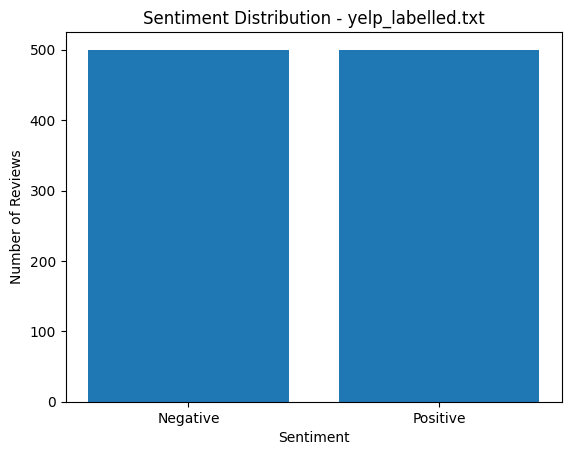

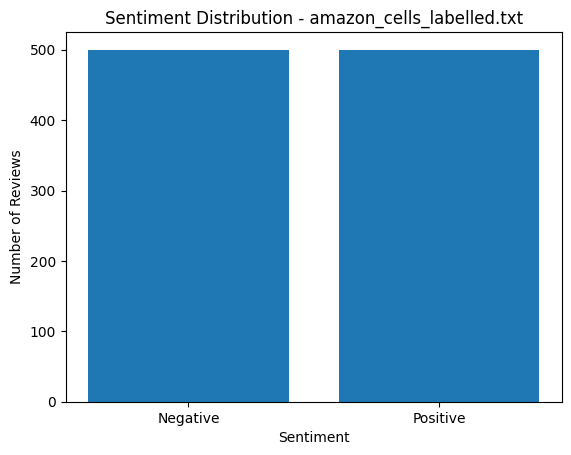

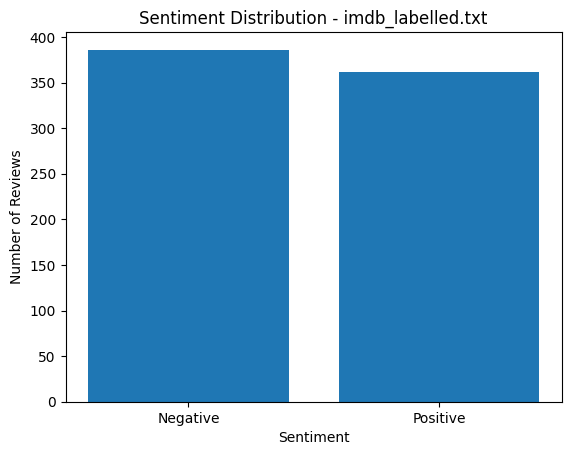

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# List of files
files = ['yelp_labelled.txt', "amazon_cells_labelled.txt", 'imdb_labelled.txt']

# Loop through files
for file in files:
    df = pd.read_csv(file, sep='\t', header=None, names=['text', 'label'])
    counts = df['label'].value_counts()
    
    plt.bar(['Negative', 'Positive'], counts)
    plt.title(f'Sentiment Distribution - {file}')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.show()


 The data in the first two datasets is roughly balanced between positive and negative classes, whereas the third dataset (IMDb ratings) has a slightly higher number of negative samples; however, this minor imbalance can be safely ignored.

## KNN (PSO)

In [4]:
import pandas as pd

files = ["yelp_labelled.txt", "imdb_labelled.txt", "amazon_cells_labelled.txt"]

dfs = [pd.read_csv(f, sep='\t', header=None, names=['statement', 'value']) for f in files]

data = pd.concat(dfs, ignore_index=True)

X = data['statement']
y = data['value']


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer(max_features=500)  # limit vocab for PSO
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)


In [6]:
from pyswarm import pso
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
import numpy as np

def objective(features_mask):
    features_mask = np.array(features_mask) > 0.5
    if np.sum(features_mask) == 0:
        return 1.0  # penalty for empty feature set
    X_train_sel = X_train_vect[:, features_mask]
    X_test_sel = X_test_vect[:, features_mask]
    
    model = MultinomialNB()
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    return 1 - f1  # PSO minimizes


In [7]:
num_features = X_train_vect.shape[1]
lb = [0] * num_features
ub = [1] * num_features

best_features, best_cost = pso(objective, lb, ub, swarmsize=10, maxiter=5)

print("Best F1 Score:", 1 - best_cost)


Stopping search: maximum iterations reached --> 5
Best F1 Score: 0.7346938775510204


In [9]:
from sklearn.metrics import confusion_matrix, f1_score

best_mask = np.array(best_features) > 0.5

X_train_sel = X_train_vect[:, best_mask]
X_test_sel = X_test_vect[:, best_mask]

model = MultinomialNB()
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Specificity:", specificity)


Specificity: 0.7013422818791947


## KNN (GA)